# Solución de la ecuación de Van der Pol

$$\dot x_1 = x_2, \qquad \dot x_2 = -\frac{x_1}{LC} - \frac{m}{C}(x_1^2-1)x_2$$

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `vdp2.m`)

In [2]:
def vdp2(t, x, m, C, L):
    """
    Derivadas de las variables de estado de la ecuacion de Van der Pol.
    Los parametros m, C, L se pasan como argumentos en vez de definirse
    dentro de la funcion, para poder explorar distintos valores facilmente.
    """
    x1, x2 = x
    xdot1 = x2
    xdot2 = -x1/(L*C) - m/C*(x1**2 - 1)*x2
    return [xdot1, xdot2]

## Solución para una condición inicial dada

In [ ]:
x0 = [3, -1]
m = 1
C = 1
L = 1

sol = solve_ivp(vdp2, [0, 50], x0, args=(m, C, L), max_step=0.05)

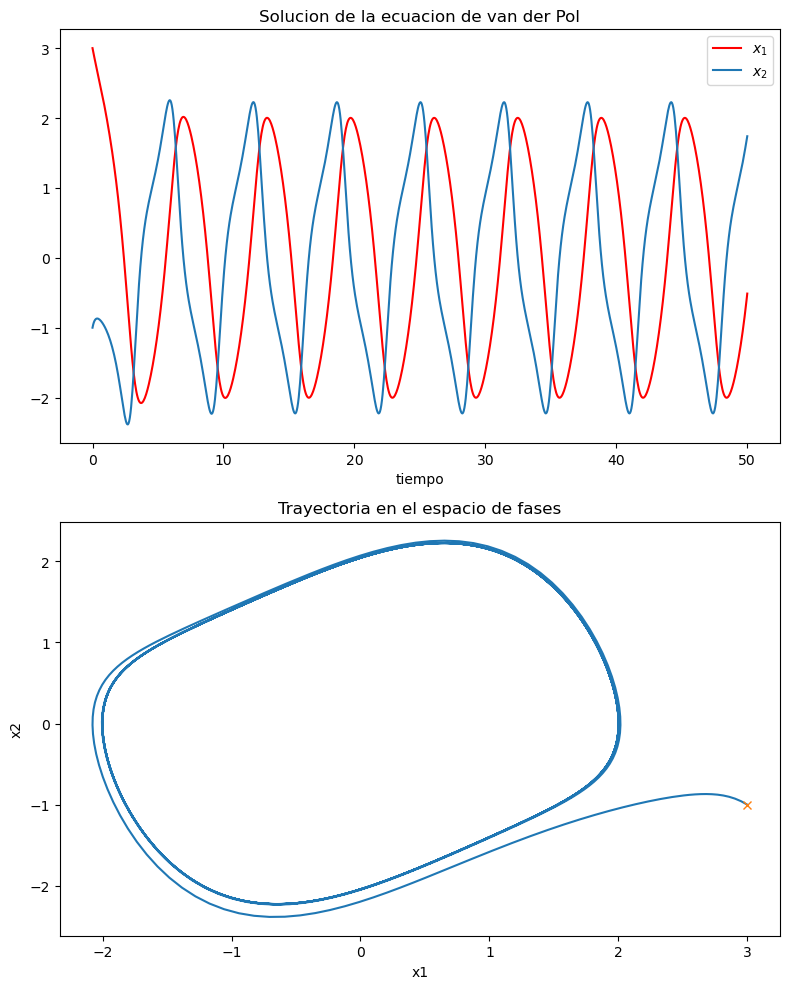

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

axs[0].plot(sol.t, sol.y[0], 'r', label='$x_1$')
axs[0].plot(sol.t, sol.y[1], label='$x_2$')
axs[0].set_title('Solucion de la ecuacion de van der Pol')
axs[0].set_xlabel('tiempo')
axs[0].legend()

axs[1].plot(sol.y[0], sol.y[1])
axs[1].plot(x0[0], x0[1], 'x')
axs[1].set_title('Trayectoria en el espacio de fases')
axs[1].set_xlabel('x1')
axs[1].set_ylabel('x2')

plt.tight_layout()
plt.show()

## Mapa de fases

Creamos una región de interés en torno al origen, que es el punto de equilibrio. Podemos modificar los parámetros del integrador — aquí se ajustan la tolerancia relativa y el paso máximo de integración (equivalente a `odeset('Reltol',1e-9,'MaxStep',1e-1)`) para asegurar que las curvas obtenidas sean suaves.

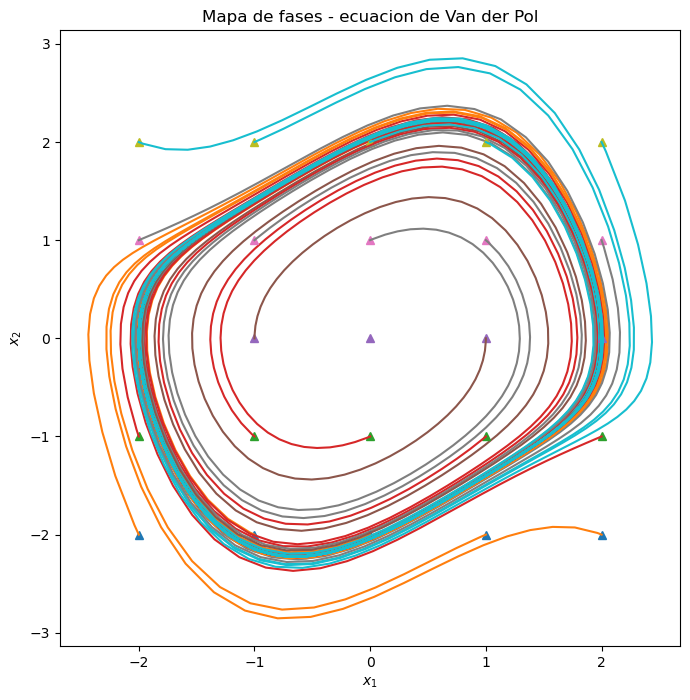

In [5]:
x10 = np.arange(-2, 2.001, 1)
x20 = np.arange(-2, 2.001, 1)

fig, ax = plt.subplots(figsize=(8, 8))

for i in x10:
    for j in x20:
        sol = solve_ivp(vdp2, [0, 50], [i, j], args=(m, C, L),
                         rtol=1e-9, max_step=1e-1)
        ax.plot(i, j, '^')
        ax.plot(sol.y[0], sol.y[1])

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Mapa de fases - ecuacion de Van der Pol')
plt.show()

Todas las trayectorias, sea cual sea el punto de partida, terminan convergiendo hacia el mismo ciclo límite — la firma característica del oscilador de Van der Pol.